# 04 — Customer Analysis

## 1. Objetivo del análisis

Hasta este punto, el análisis se ha centrado principalmente en el comportamiento de las **sesiones** dentro del e-commerce.

En este notebook cambiaremos la unidad de análisis:

> Pasaremos de estudiar qué ocurre dentro de una sesión a estudiar cómo se comportan los usuarios a través de múltiples sesiones.

El objetivo es comprender el comportamiento individual de los clientes y responder preguntas relacionadas con:

- recurrencia;
- frecuencia de interacción;
- conversión;
- comportamiento antes y después de una compra;
- comportamiento entre sesiones;
- recuperación de usuarios;
- intención de compra;
- relación entre diferentes sesiones de un mismo usuario.

Este análisis busca generar insights útiles para:

- **Marketing**
- **CRO (Conversion Rate Optimization)**
- **Commercial Analytics**
- **Customer Analytics**

No se busca todavía construir una segmentación RFM, analizar cohortes o calcular Customer Lifetime Value. Estos análisis se reservarán para notebooks posteriores.

---

# 2. Cambio de unidad de análisis

En el Notebook 03 la principal unidad de análisis fue la **sesión**.

En este notebook la unidad principal será el **usuario (`user_id`)**.

La estructura conceptual será:

```text
Evento
   ↓
Sesión
   ↓
Usuario

## **1. Carga y preparacion**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [2]:
import importlib
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "src" / "data" / "loading.py").exists():
    project_root = project_root.parent

if not (project_root / "src" / "data" / "loading.py").exists():
    raise FileNotFoundError("No se encontró la raíz del proyecto con src/data/loading.py")

project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

for module_name in ("src.data.loading", "src.data", "src"):
    sys.modules.pop(module_name, None)
importlib.invalidate_caches()

from src.data.loading import load_parquet

#### Definicion de paleta de colores para las visualizaciones

In [3]:
NS_BG = "#E8E8E8"
NS_INK = "#292929"
NS_ACCENT = "#1B6B45"

# Variantes de peso/alpha para jerarquía sin usar semántica roja/verde
NS_INK_70 = "#292929B3"   # alpha 70%
NS_INK_40 = "#29292966"   # alpha 40%
NS_INK_15 = "#29292926"   # alpha 15% — gridlines, bordes suaves

plt.rcParams.update({
    # Fuentes
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "Arial", "DejaVu Sans"],
    "font.weight": "regular",

    # Colores base
    "figure.facecolor": NS_BG,
    "axes.facecolor": NS_BG,
    "savefig.facecolor": NS_BG,
    "text.color": NS_INK,
    "axes.labelcolor": NS_INK,
    "axes.titlecolor": NS_INK,
    "xtick.color": NS_INK_70,
    "ytick.color": NS_INK_70,

    # Ejes — sin caja, jerarquía por peso
    "axes.edgecolor": NS_INK_40,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,

    # Grid — sutil, nunca protagonista
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": NS_INK_15,
    "grid.linewidth": 0.6,
    "grid.linestyle": "-",
    "axes.axisbelow": True,

    # Ciclo de color — monocromático con acento esmeralda como único highlight
    "axes.prop_cycle": plt.cycler(color=[NS_ACCENT, NS_INK, NS_INK_70, NS_INK_40]),

    # Tamaños
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Leyenda — sin caja, minimal
    "legend.frameon": False,
    "legend.loc": "best",

    # Export
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

#### Carga de datos

In [4]:
DATA_PATH = "../data/processed/"

In [5]:
df = load_parquet(DATA_PATH + "ecommerce_clean.parquet")

In [6]:
df.shape

(2074532, 10)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2074532 entries, 0 to 2074531
Data columns (total 10 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     str                
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  str                
 5   brand          str                
 6   price          float64            
 7   user_id        int64              
 8   user_session   str                
 9   month          period[M]          
dtypes: datetime64[us, UTC](1), float64(1), int64(3), period[M](1), str(4)
memory usage: 251.4 MB


In [8]:
df.head(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,month
0,2019-10-01 00:01:46+00:00,view,5843665,1487580005092295511,NaN,f.o.x,9.44,462033176,a18e0999-61a1-4218-8f8f-61ec1d375361,2019-10
1,2019-10-01 00:01:55+00:00,cart,5868461,1487580013069861041,NaN,italwax,3.57,514753614,e2fecb2d-22d0-df2c-c661-15da44b3ccf1,2019-10
2,2019-10-01 00:02:50+00:00,view,5877456,1487580006300255120,NaN,jessnail,122.22,527418424,86e77869-afbc-4dff-9aa2-6b7dd8c90770,2019-10
3,2019-10-01 00:03:41+00:00,view,5649270,1487580013749338323,NaN,concept,6.19,555448072,b5f72ceb-0730-44de-a932-d16db62390df,2019-10
4,2019-10-01 00:03:44+00:00,view,18082,1487580005411062629,NaN,cnd,16.03,552006247,2d8f304b-de45-4e59-8f40-50c603843fe5,2019-10


## **2. Radiografia de clientes**

In [9]:
unique_users = df['user_id'].nunique()
unique_users

163781

In [10]:
# usuarios compradores y no compradores

buyers = df.loc[df["event_type"] == "purchase", "user_id"].nunique()

non_buyers = unique_users - buyers

user_conversion_rate = buyers / unique_users * 100

print(f"Usuarios totales: {unique_users}")
print(f"Compradores: {buyers}")
print(f"Usuarios que no compraron: {non_buyers}")
print(f"Proporción de conversión: {user_conversion_rate:.2f}%")

Usuarios totales: 163781
Compradores: 11040
Usuarios que no compraron: 152741
Proporción de conversión: 6.74%


In [11]:
# Usuarios single session vs recurrente

sessions_per_user = (
    df.groupby("user_id")["user_session"]
    .nunique()
)

# usuarios single-sesion
single_session_users = (sessions_per_user == 1).sum()

# usuarios recurrentes
repeat_users = (sessions_per_user > 1).sum()

# proporciones
single_session_rate = single_session_users / unique_users * 100
repeat_user_rate = repeat_users / unique_users * 100

print(f"Usuarios con una sola sesión: {single_session_users}")
print(f"Usuarios con 2+ sesiones: {repeat_users}")
print(f"Total de usuarios: {unique_users}")
print(f"Proporción de usuarios con una sola sesión: {single_session_rate:.2f}%")
print(f"Proporción de usuarios recurrentes: {repeat_user_rate:.2f}%")

Usuarios con una sola sesión: 108362
Usuarios con 2+ sesiones: 55403
Total de usuarios: 163781
Proporción de usuarios con una sola sesión: 66.16%
Proporción de usuarios recurrentes: 33.83%


In [12]:
sessions_per_user.describe()

count    163781.000000
mean          2.723527
std          11.202608
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        1713.000000
Name: user_session, dtype: float64

#### Nota sobre eventos sin `user_session`

Durante la construcción de la tabla `customer_summary` se identificaron **506 eventos (0.02% del total)** con `user_session` nulo, correspondientes a **146 usuarios (0.09% de la base)**.

Estos eventos corresponden principalmente a:

- `cart`: 417 eventos (82.41%)
- `remove_from_cart`: 85 eventos (16.80%)
- `view`: 4 eventos (0.79%)

No se identificaron eventos `purchase` sin `user_session`.

De los 146 usuarios afectados, **130 también presentan sesiones válidas**, mientras que **16 usuarios únicamente presentan eventos sin una sesión identificable**.

Debido a que no existe información suficiente para reconstruir de forma fiable estas sesiones, **no se realizó imputación de `user_session`**.

Los eventos se conservarán para análisis a nivel usuario, donde `user_id` permite atribuir correctamente la actividad al cliente. Sin embargo, estos eventos no se utilizarán para métricas que requieran identificar una sesión específica.

Para evitar interpretaciones incorrectas, la métrica de sesiones se denominará `known_sessions`, representando únicamente las sesiones identificables mediante `user_session`.

In [13]:
df[df["user_id"] == 559219168]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,month
156754,2019-10-11 15:56:49+00:00,cart,5645768,1487580007717929935,NaN,NaN,1.59,559219168,NaN,2019-10


In [14]:
df["user_session"].isna().sum()

np.int64(506)

In [15]:
missing_sessions = df["user_session"].isna().sum()
total_events = len(df)

missing_session_rate = missing_sessions / total_events * 100

print(f"Eventos con user_session nulo: {missing_sessions:,}")
print(f"Porcentaje: {missing_session_rate:.2f}%")

Eventos con user_session nulo: 506
Porcentaje: 0.02%


In [16]:
users_with_missing_session = (
    df.loc[df["user_session"].isna(), "user_id"]
    .nunique()
)

print(f"Usuarios afectados: {users_with_missing_session:,}")

Usuarios afectados: 146


In [17]:
users_with_missing_session / df["user_id"].nunique() * 100

0.08914342933551511

In [18]:
df.loc[df["user_session"].isna(), "event_type"].value_counts()

event_type
cart                417
remove_from_cart     85
view                  4
Name: count, dtype: int64

In [19]:
df.loc[df["user_session"].isna(), "event_type"].value_counts(normalize=True) * 100

event_type
cart                82.411067
remove_from_cart    16.798419
view                 0.790514
Name: proportion, dtype: float64

In [20]:
users_missing_session = df.loc[
    df["user_session"].isna(), "user_id"
].unique()

user_session_check = (
    df[df["user_id"].isin(users_missing_session)]
    .groupby("user_id")["user_session"]
    .apply(lambda x: x.notna().any())
)

user_session_check.value_counts()

user_session
True     130
False     16
Name: count, dtype: int64

#### resumen

In [21]:
# resumen de los clientes

df = df.assign(
    is_cart=df["event_type"].eq("cart"),
    is_purchase=df["event_type"].eq("purchase"),
    purchase_revenue=np.where(df["event_type"].eq("purchase"), df["price"], 0),
    is_missing_session=df["user_session"].isna(),
)

customer_summary = (
    df.assign(event_date=df["event_time"].dt.normalize())
    .groupby("user_id", sort=False)
    .agg(
        known_sessions=("user_session", "nunique"),
        sessions=("user_session", "nunique"),
        events=("event_type", "size"),
        active_days=("event_date", "nunique"),
        products_interacted=("product_id", "nunique"),
        cart_events=("is_cart", "sum"),
        purchase_events=("is_purchase", "sum"),
        revenue=("purchase_revenue", "sum"),
        events_without_session=("is_missing_session", "sum"),
    )
    .reset_index()
)


In [22]:
customer_summary.head()

,user_id,known_sessions,sessions,events,active_days,products_interacted,cart_events,purchase_events,revenue,events_without_session
0,462033176,3,3,3,1,1,0,0,0.0,0
1,514753614,5,5,45,4,27,4,0,0.0,0
2,527418424,4,4,13,4,7,0,0,0.0,0
3,555448072,2,2,2,1,1,0,0,0.0,0
4,552006247,4,4,4,2,2,0,0,0.0,0


In [23]:
customer_summary.shape

(163781, 10)

In [24]:
customer_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 163781 entries, 0 to 163780
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   user_id                 163781 non-null  int64  
 1   known_sessions          163781 non-null  int64  
 2   sessions                163781 non-null  int64  
 3   events                  163781 non-null  int64  
 4   active_days             163781 non-null  int64  
 5   products_interacted     163781 non-null  int64  
 6   cart_events             163781 non-null  int64  
 7   purchase_events         163781 non-null  int64  
 8   revenue                 163781 non-null  float64
 9   events_without_session  163781 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 12.5 MB


In [25]:
customer_summary["user_id"].nunique() == len(customer_summary)

True

In [26]:
customer_summary.describe()

,user_id,known_sessions,sessions,events,active_days,products_interacted,cart_events,purchase_events,revenue,events_without_session
count,1.637810e+05,163781.000000,163781.000000,163781.000000,163781.000000,163781.000000,163781.000000,163781.000000,163781.000000,163781.000000
mean,5.579380e+08,2.723527,2.723527,12.666500,1.713404,6.216899,3.510566,0.778869,3.795004,0.003089
std,6.589670e+07,11.202608,11.202608,69.177258,2.781606,25.700202,21.097804,5.524093,25.485196,0.243168
min,4.661182e+06,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.556370e+08,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,5.730579e+08,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,5.987132e+08,2.000000,2.000000,4.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000
max,6.220880e+08,1713.000000,1713.000000,8066.000000,116.000000,1635.000000,2676.000000,506.000000,1559.210000,78.000000


In [27]:
customer_summary[customer_summary["revenue"] > 0].shape

(11040, 10)

In [28]:
total_revenue_buyers = customer_summary.loc[
    customer_summary["revenue"] > 0, "revenue"
].sum()

print(f"Revenue total de usuarios compradores: {total_revenue_buyers:,.2f}")

Revenue total de usuarios compradores: 621,549.60


In [29]:
buyers_summary = customer_summary[
    customer_summary["purchase_events"] > 0
].copy()

In [30]:
top_10_buyers_n = int(len(buyers_summary) * 0.10)

print(f"Top 10% de compradores: {top_10_buyers_n:,}")

Top 10% de compradores: 1,104


In [31]:
buyers_sorted = buyers_summary.sort_values(
    "revenue",
    ascending=False
)

In [32]:
top_10_buyers = buyers_sorted.head(top_10_buyers_n)

In [33]:
top_10_buyer_revenue = top_10_buyers["revenue"].sum()
total_buyer_revenue = buyers_summary["revenue"].sum()

top_10_buyer_share = (
    top_10_buyer_revenue / total_buyer_revenue * 100
)

print(f"Revenue Top 10% de compradores: {top_10_buyer_revenue:,.2f}")
print(f"Revenue total de compradores: {total_buyer_revenue:,.2f}")
print(f"Participación: {top_10_buyer_share:.2f}%")

Revenue Top 10% de compradores: 263,768.62
Revenue total de compradores: 621,549.60
Participación: 42.44%


Al analizar únicamente a los usuarios que realizaron al menos una compra, se observa una concentración relevante del revenue.

El **10% de los compradores con mayor revenue**, equivalente a **1,104 compradores**, generó **Bs. 263,768.62**, representando el **42.44% del revenue total generado por compradores (Bs. 621,549.60)**.

Este resultado indica que una proporción relativamente pequeña de los compradores concentra una parte significativa de los ingresos del e-commerce.

> **Insight descriptivo:** existe una concentración relevante del revenue entre los compradores de mayor valor.

Este hallazgo no implica necesariamente que el negocio dependa de estos clientes ni que sean clientes recurrentes o fieles, ya que la clasificación se realizó retrospectivamente utilizando el revenue acumulado durante todo el período analizado. Se requeriría analizar recurrencia, frecuencia de compra y comportamiento temporal para determinar la naturaleza de estos compradores.

In [34]:
# concentracion del revenue

percentiles = [0.01, 0.05, 0.10, 0.20, 0.50, 1.00]

In [35]:
concentration = []

buyers_sorted = buyers_summary.sort_values(
    "revenue",
    ascending=False
)

total_revenue = buyers_sorted["revenue"].sum()

for p in percentiles:
    n_users = int(len(buyers_sorted) * p)

    top_users = buyers_sorted.head(n_users)

    revenue = top_users["revenue"].sum()

    revenue_share = revenue / total_revenue * 100

    concentration.append({
        "Top": f"{p:0%}",
        "Buyers": n_users,
        "Revenue": revenue,
        "Revenue Share": revenue_share,
    })


concentration_df = pd.DataFrame(concentration)

concentration_df

,Top,Buyers,Revenue,Revenue Share
0,1.000000%,110,65594.93,10.553451
1,5.000000%,552,181143.54,29.143859
2,10.000000%,1104,263768.62,42.437260
3,20.000000%,2208,366296.18,58.932735
4,50.000000%,5520,526168.79,84.654353
5,100.000000%,11040,621549.60,100.000000


### Insight — Concentración de Revenue

El revenue presenta una concentración significativa entre los compradores de mayor valor.

El **1% de los compradores concentra el 10.55% del revenue**, mientras que el **10% concentra el 42.44%**. A su vez, el **20% concentra el 58.93%** y el **50% de los compradores genera el 84.65% del revenue total**.

Estos resultados muestran que el valor económico no está distribuido uniformemente entre los compradores, sino que existe una estructura de concentración progresiva hacia los clientes de mayor valor.

Este análisis es descriptivo y retrospectivo: los compradores fueron ordenados según el revenue acumulado durante todo el período analizado. Por lo tanto, estos resultados no permiten afirmar todavía que los clientes de mayor valor sean más recurrentes, fieles o de mayor valor futuro.

Será necesario analizar posteriormente su frecuencia de compra, recurrencia y comportamiento para determinar qué características diferencian a estos compradores.

## **3. Comportamiento y recurrencia**

#### **3.1 Recurrencia y conversion**
Comparar usuarios segun su comportamiento recurrente
- Probabilidad de compra
- Numero de compras
- Revenue
- Numero de productos

In [36]:
user_behavior = (
    df.groupby("user_id")
      .agg(
          session_count=("user_session", "nunique")
      )
      .reset_index()
)

In [37]:
user_purchase = (
    df[df["event_type"] == "purchase"]
    .groupby("user_id")
    .agg(
        purchase_events=("event_type", "size"),
        revenue=("price", "sum")
    )
    .reset_index()
)

In [38]:
user_behavior = user_behavior.merge(
    user_purchase,
    on="user_id",
    how="left"
)

In [39]:
user_behavior[["purchase_events", "revenue"]] = (
    user_behavior[["purchase_events", "revenue"]]
    .fillna(0)
)

In [40]:
user_behavior["purchased"] = (
    user_behavior["purchase_events"] > 0
).astype(int)

In [41]:
user_products = (
    df.groupby("user_id")
      .agg(
          unique_products=("product_id", "nunique")
      )
      .reset_index()
)

In [42]:
user_behavior = user_behavior.merge(
    user_products,
    on="user_id",
    how="left"
)

In [43]:
user_behavior[user_behavior["purchased"] > 0]

,user_id,session_count,purchase_events,revenue,purchased,unique_products
5,25392526,6,3.0,22.14,1,11
9,27756757,1,1.0,20.63,1,2
37,50748978,11,9.0,10.01,1,25
39,52747911,2,3.0,23.02,1,10
49,65241811,17,5.0,41.79,1,149
...,...,...,...,...,...,...
163590,621995551,1,5.0,10.46,1,6
163653,622021687,2,1.0,13.33,1,1
163693,622041514,1,3.0,1.90,1,6
163695,622042698,1,3.0,84.13,1,6


In [44]:
user_behavior["recurrence_group"] = pd.cut(
    user_behavior["session_count"],
    bins=[0, 1, 2, float("inf")],
    labels=["1 sesion", "2 sesiones", "3+ sesiones"]
)

In [45]:
user_behavior["recurrence_group"].value_counts().sort_index()

recurrence_group
1 sesion       108362
2 sesiones      25385
3+ sesiones     30018
Name: count, dtype: int64

In [46]:
recurrence_analysis = (
    user_behavior
    .groupby("recurrence_group", observed=True)
    .agg(
        users=("user_id", "nunique"),
        buyers=("purchased", "sum")
    )
    .reset_index()
)

recurrence_analysis["purchase_rate"] = (
    recurrence_analysis["buyers"] /
    recurrence_analysis["users"]
)

In [47]:
recurrence_analysis

,recurrence_group,users,buyers,purchase_rate
0,1 sesion,108362,2306,0.021281
1,2 sesiones,25385,1430,0.056332
2,3+ sesiones,30018,7304,0.243321


In [48]:
purchase_frequency = (
    user_behavior
    .groupby("recurrence_group", observed=True)
    .agg(
        users=("user_id", "nunique"),
        avg_purchase_events=("purchase_events", "mean"),
        median_purchase_events=("purchase_events", "median")
    )
    .reset_index()
)

In [49]:
revenue_analysis = (
    user_behavior
    .groupby("recurrence_group", observed=True)
    .agg(
        users=("user_id", "nunique"),
        total_revenue=("revenue", "sum"),
        avg_revenue_per_user=("revenue", "mean"),
        median_revenue_per_user=("revenue", "median")
    )
    .reset_index()
)

In [50]:
product_analysis = (
    user_behavior
    .groupby("recurrence_group", observed=True)
    .agg(
        users=("user_id", "nunique"),
        avg_unique_products=("unique_products", "mean"),
        median_unique_products=("unique_products", "median")
    )
    .reset_index()
)

In [51]:
recurrence_summary = (
    user_behavior
    .groupby("recurrence_group", observed=True)
    .agg(
        users=("user_id", "nunique"),
        purchase_rate=("purchased", "mean"),
        avg_purchase_events=("purchase_events", "mean"),
        median_purchase_events=("purchase_events", "median"),
        avg_revenue=("revenue", "mean"),
        median_revenue=("revenue", "median"),
        avg_unique_products=("unique_products", "mean"),
        median_unique_products=("unique_products", "median")
    )
    .reset_index()
)

In [52]:
recurrence_summary

,recurrence_group,users,purchase_rate,avg_purchase_events,median_purchase_events,avg_revenue,median_revenue,avg_unique_products,median_unique_products
0,1 sesion,108362,0.021281,0.137742,0.0,0.747135,0.0,1.982392,1.0
1,2 sesiones,25385,0.056332,0.352373,0.0,2.066917,0.0,3.757928,2.0
2,3+ sesiones,30018,0.243321,3.454361,0.0,16.260904,0.0,23.585016,7.0


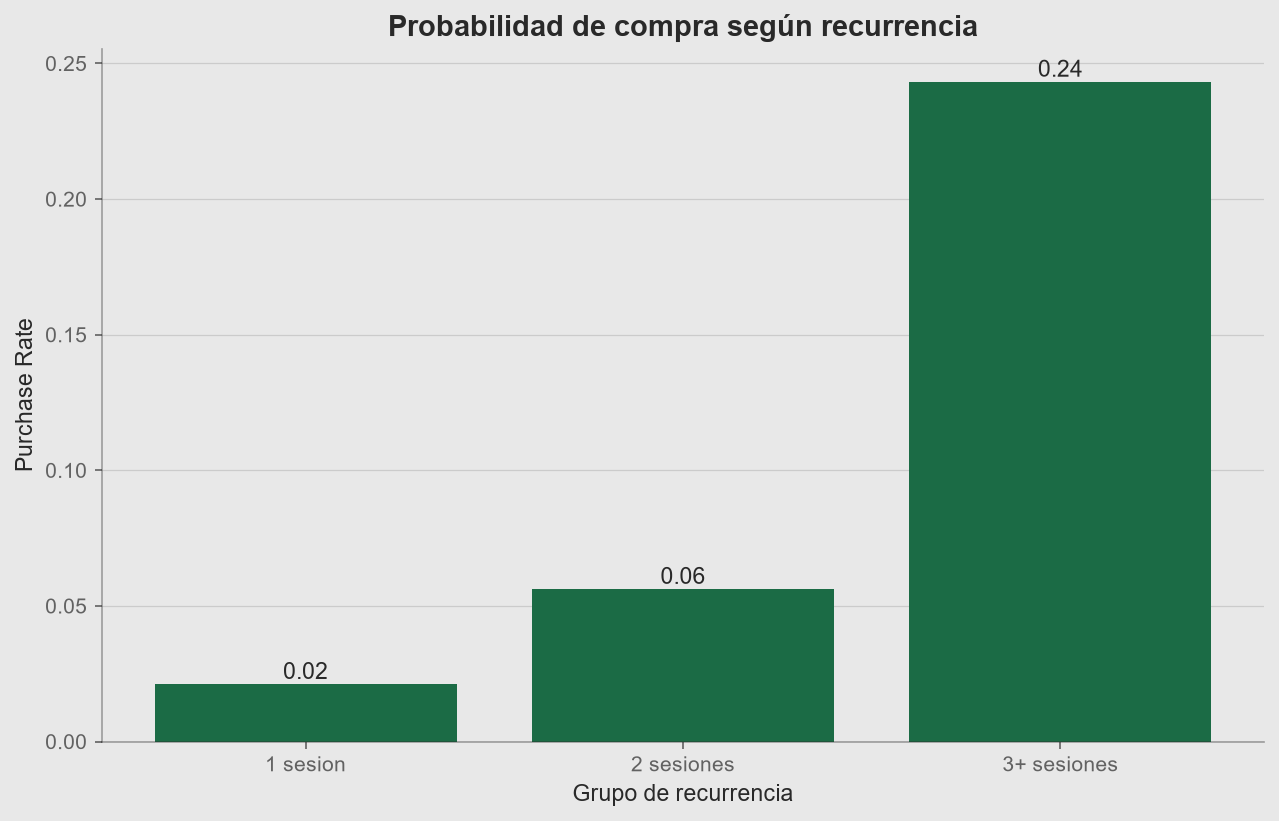

In [53]:
plt.figure(figsize=(10, 6))

plt.bar(
    recurrence_summary["recurrence_group"],
    recurrence_summary["purchase_rate"]
)

for i, value in enumerate(recurrence_summary["purchase_rate"]):
    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Probabilidad de compra según recurrencia")
plt.xlabel("Grupo de recurrencia")
plt.ylabel("Purchase Rate")

plt.show()

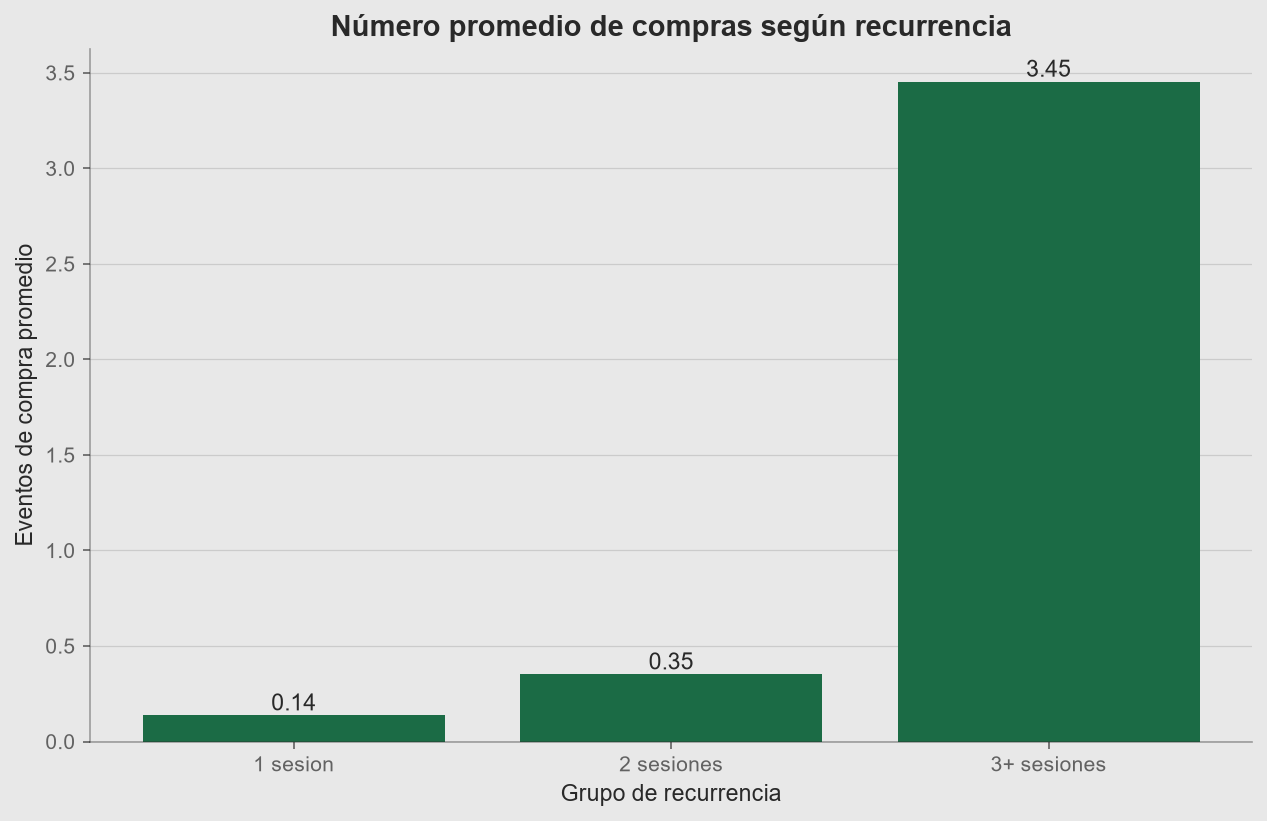

In [54]:
plt.figure(figsize=(10, 6))

plt.bar(
    purchase_frequency["recurrence_group"],
    purchase_frequency["avg_purchase_events"]
)

for i, value in enumerate(purchase_frequency["avg_purchase_events"]):
    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Número promedio de compras según recurrencia")
plt.xlabel("Grupo de recurrencia")
plt.ylabel("Eventos de compra promedio")

plt.show()

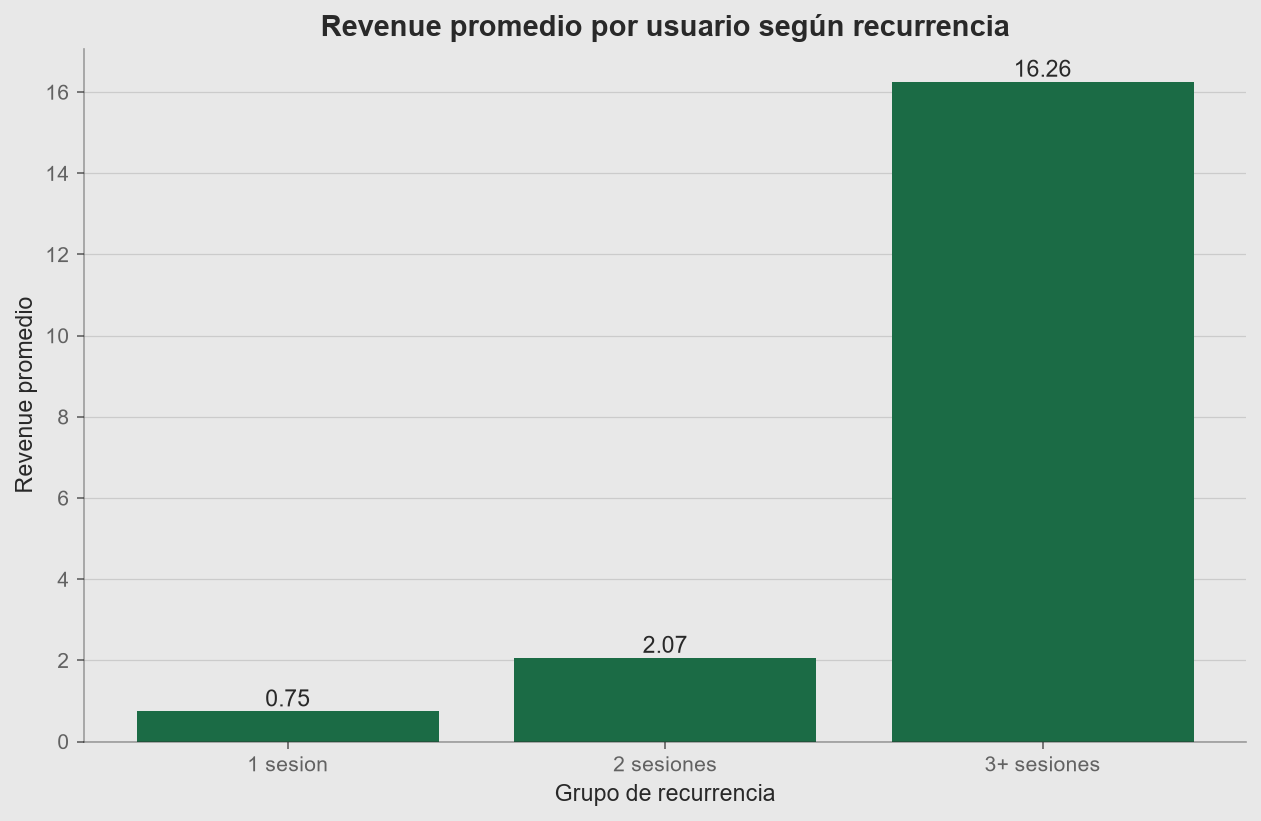

In [55]:
plt.figure(figsize=(10, 6))

plt.bar(
    revenue_analysis["recurrence_group"],
    revenue_analysis["avg_revenue_per_user"]
)

for i, value in enumerate(revenue_analysis["avg_revenue_per_user"]):
    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Revenue promedio por usuario según recurrencia")
plt.xlabel("Grupo de recurrencia")
plt.ylabel("Revenue promedio")

plt.show()

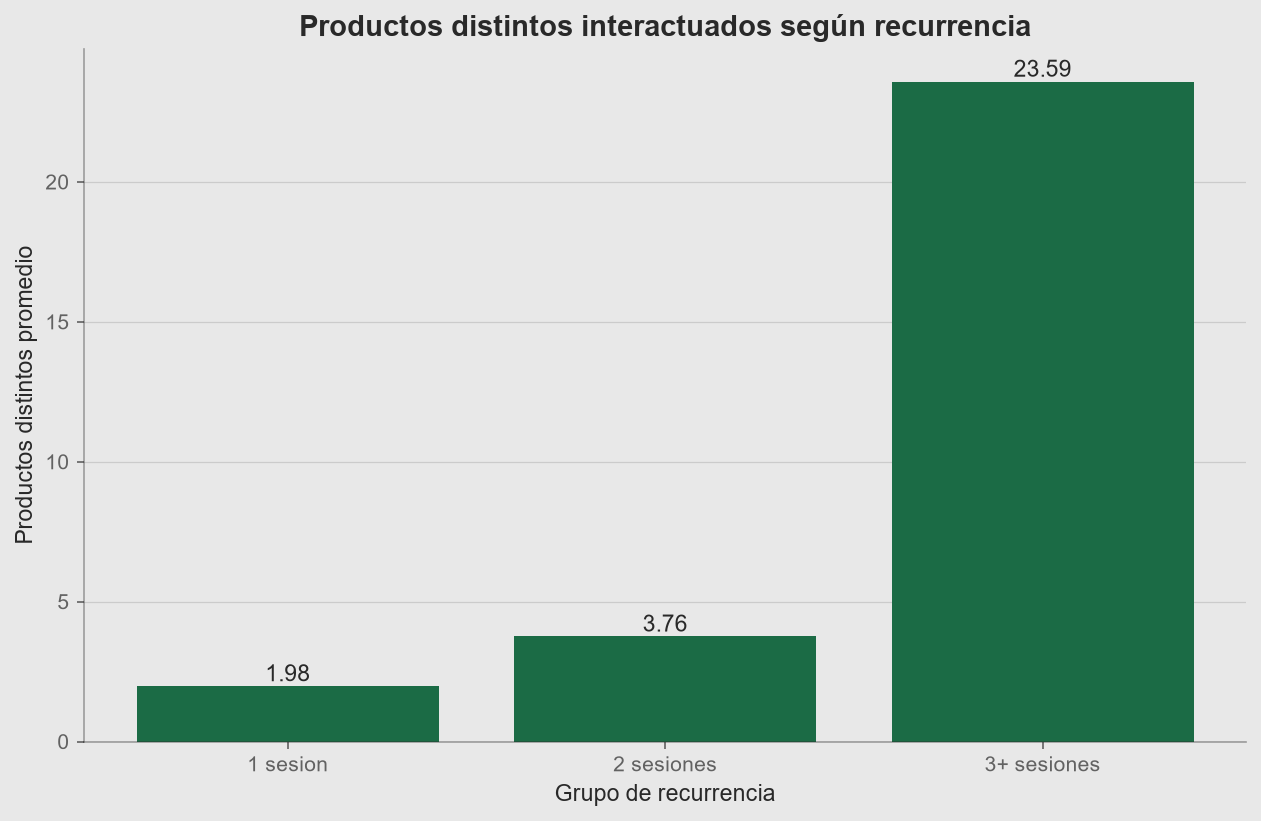

In [56]:
plt.figure(figsize=(10, 6))

plt.bar(
    product_analysis["recurrence_group"],
    product_analysis["avg_unique_products"]
)

for i, value in enumerate(product_analysis["avg_unique_products"]):
    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Productos distintos interactuados según recurrencia")
plt.xlabel("Grupo de recurrencia")
plt.ylabel("Productos distintos promedio")

plt.show()

Los usuarios con mayor recurrencia presentan simultaneamente mayor probabilidad de compra, mayor numero de eventos de compra, mayor revenue y mayor exploracion del catalogo.

**Ojo**
Esto no es un modelo predictivo de compras para usuarios en base al numero de sesiones

#### **3.3 Intencion nocturna -> Compra posterior**

¿Los usuarios que muestran intencion de compra durante la noche tienen una mayor probabilidad de realizar una compra posteriormente, especialmente durante el dia?

**Hipotesis que queremos investigar**
- H1: Una parte de los usuarios que interactuan con productos durante la noche no compra inmediatamente, sino que regresa posteriormete y realiza una compra durante el di

**Importante:** No queremos demostrar causalidad. Queremos determinar si existe un patron suficientemente consistente como para justificar una investigacion posterior.

In [57]:
df["hour"] = df["event_time"].dt.hour

df["is_night"] = (
    (df["hour"] >= 21) |
    (df["hour"] < 6)
)

In [58]:
night_users = (
    df.groupby("user_id")["is_night"]
      .any()
      .reset_index(name="night_user")
)

night_users["night_user"] = night_users["night_user"].astype(int)

night_users.head()

,user_id,night_user
0,4661182,1
1,11253733,0
2,15811955,1
3,22050296,1
4,24823595,1


In [59]:
night_user_summary = (
    night_users["night_user"]
    .value_counts(normalize=True)
    .mul(100)
)

night_user_summary

night_user
0    77.127384
1    22.872616
Name: proportion, dtype: float64

In [60]:
night_behavior = (
    df[df["is_night"]]
    .groupby("user_id")
    .agg(
        night_views=("event_type", lambda x: (x == "view").sum()),
        night_carts=("event_type", lambda x: (x == "cart").sum()),
        night_removes=("event_type", lambda x: (x == "remove_from_cart").sum()),
        night_purchases=("event_type", lambda x: (x == "purchase").sum())
    )
    .reset_index()
)

In [61]:
night_behavior["night_view"] = (
    night_behavior["night_views"] > 0
).astype(int)

night_behavior["night_cart"] = (
    night_behavior["night_carts"] > 0
).astype(int)

night_behavior["night_purchase"] = (
    night_behavior["night_purchases"] > 0
).astype(int)

In [62]:
night_analysis = (
    night_users
    .merge(
        night_behavior,
        on="user_id",
        how="left"
    )
    .fillna(0)
)

In [63]:
night_analysis["night_intent_group"] = "Sin actividad nocturna"

night_analysis.loc[
    night_analysis["night_view"] == 1,
    "night_intent_group"
] = "View nocturno"

night_analysis.loc[
    night_analysis["night_cart"] == 1,
    "night_intent_group"
] = "Cart nocturno"

In [64]:
last_night_activity = (
    df[df["is_night"]]
    .groupby("user_id")["event_time"]
    .max()
    .reset_index(name="last_night_activity")
)

In [65]:
night_analysis = night_analysis.merge(
    last_night_activity,
    on="user_id",
    how="left"
)

In [66]:
purchases = (
    df[df["event_type"] == "purchase"]
    [["user_id", "event_time", "product_id"]]
    .rename(columns={
        "event_time": "purchase_time",
        "product_id": "purchase_product_id"
    })
)

In [67]:
night_purchase_check = night_analysis.merge(
    purchases,
    on="user_id",
    how="left"
)

In [68]:
night_purchase_check["hours_to_purchase"] = (
    night_purchase_check["purchase_time"]
    - night_purchase_check["last_night_activity"]
).dt.total_seconds() / 3600

In [69]:
night_purchase_check["purchase_within_24h"] = (
    (night_purchase_check["hours_to_purchase"] > 0) &
    (night_purchase_check["hours_to_purchase"] <= 24)
)

In [70]:
post_purchase_24h = (
    night_purchase_check
    .groupby("user_id")["purchase_within_24h"]
    .any()
    .reset_index(name="purchase_after_night_24h")
)

In [71]:
night_analysis = night_analysis.merge(
    post_purchase_24h,
    on="user_id",
    how="left"
)

night_analysis["purchase_after_night_24h"] = (
    night_analysis["purchase_after_night_24h"]
    .fillna(False)
)

In [72]:
night_conversion = (
    night_analysis
    .groupby("night_intent_group")
    .agg(
        users=("user_id", "nunique"),
        purchase_after_night_24h=(
            "purchase_after_night_24h",
            "mean"
        )
    )
    .reset_index()
)

night_conversion["purchase_after_night_24h"] *= 100

night_conversion

,night_intent_group,users,purchase_after_night_24h
0,Cart nocturno,10321,5.232051
1,Sin actividad nocturna,126484,0.008697
2,View nocturno,26976,0.426305


In [73]:
night_users_analysis = night_analysis[
    night_analysis["night_user"] == 1
].copy()

In [74]:
night_users_analysis["purchase_after_night_24h"].mean() * 100

np.float64(1.7778489629214382)

In [75]:
from src.analysis.customers import calculate_post_night_purchase

In [76]:
purchase_24h = calculate_post_night_purchase(
    night_purchase_check,
    24
)

purchase_48h = calculate_post_night_purchase(
    night_purchase_check,
    48
)

purchase_7d = calculate_post_night_purchase(
    night_purchase_check,
    24 * 7
)

In [77]:
sensitivity = pd.DataFrame({
    "24H": purchase_24h,
    "48H": purchase_48h,
    "7D": purchase_7d
}).fillna(False)

sensitivity.mean().mul(100)

24H    0.406641
48H    0.495173
7D     0.679566
dtype: float64

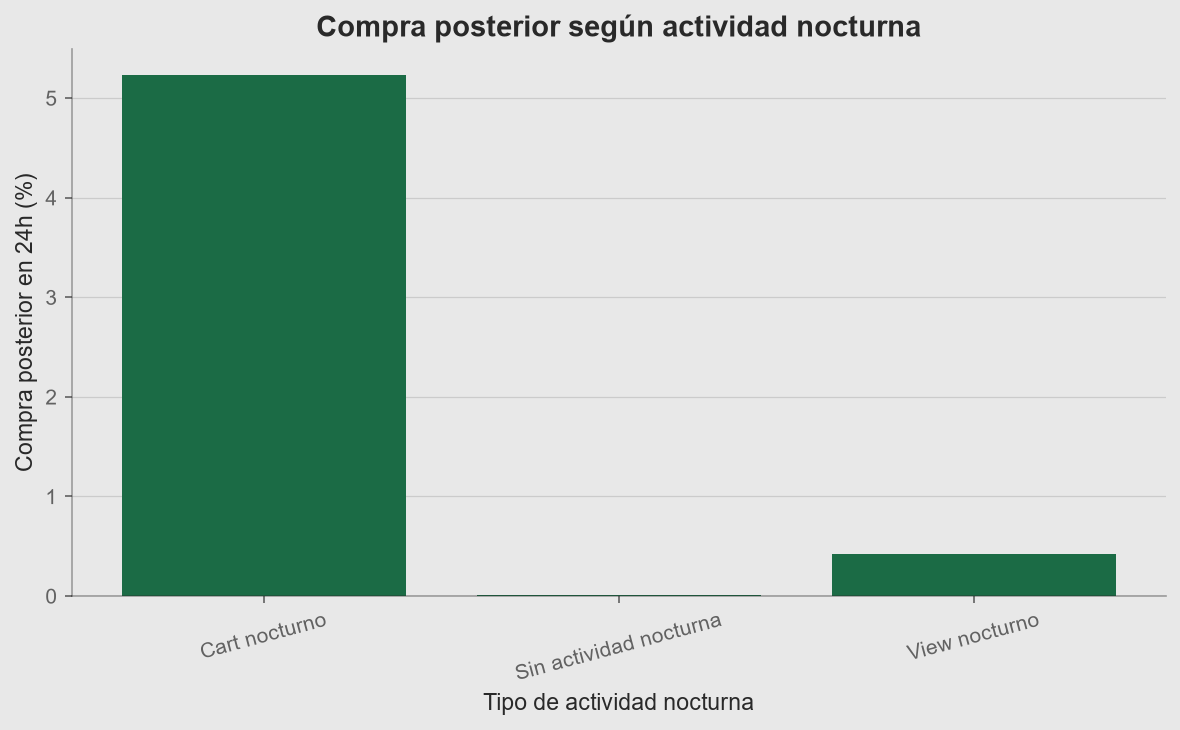

In [78]:
plot_data = night_conversion.copy()

plt.figure(figsize=(8, 5))

plt.bar(
    plot_data["night_intent_group"],
    plot_data["purchase_after_night_24h"]
)

plt.ylabel("Compra posterior en 24h (%)")
plt.xlabel("Tipo de actividad nocturna")
plt.title("Compra posterior según actividad nocturna")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [79]:
baseline = night_conversion.loc[
    night_conversion["night_intent_group"] == "Sin actividad nocturna",
    "purchase_after_night_24h"
].iloc[0]

cart_night = night_conversion.loc[
    night_conversion["night_intent_group"] == "Cart nocturno",
    "purchase_after_night_24h"
].iloc[0]

relative_lift = cart_night / baseline

relative_lift

np.float64(601.6097805885618)

In [80]:
sensitivity_check = night_purchase_check.copy()

sensitivity_check["purchase_24h"] = (
    (sensitivity_check["hours_to_purchase"] > 0) &
    (sensitivity_check["hours_to_purchase"] <= 24)
)

sensitivity_check["purchase_48h"] = (
    (sensitivity_check["hours_to_purchase"] > 0) &
    (sensitivity_check["hours_to_purchase"] <= 48)
)

sensitivity_check["purchase_7d"] = (
    (sensitivity_check["hours_to_purchase"] > 0) &
    (sensitivity_check["hours_to_purchase"] <= 24 * 7)
)

In [81]:
sensitivity_user = (
    sensitivity_check
    .groupby("user_id")
    .agg(
        night_intent_group=("night_intent_group", "first"),
        purchase_24h=("purchase_24h", "any"),
        purchase_48h=("purchase_48h", "any"),
        purchase_7d=("purchase_7d", "any")
    )
    .reset_index()
)

In [82]:
sensitivity_summary = (
    sensitivity_user
    .groupby("night_intent_group")
    .agg(
        users=("user_id", "nunique"),
        purchase_24h=("purchase_24h", "mean"),
        purchase_48h=("purchase_48h", "mean"),
        purchase_7d=("purchase_7d", "mean")
    )
    .reset_index()
)

sensitivity_summary[
    ["purchase_24h", "purchase_48h", "purchase_7d"]
] *= 100

sensitivity_summary

,night_intent_group,users,purchase_24h,purchase_48h,purchase_7d
0,Cart nocturno,10321,5.232051,6.094371,8.216258
1,Sin actividad nocturna,126484,0.008697,0.009487,0.011069
2,View nocturno,26976,0.426305,0.630190,0.930457


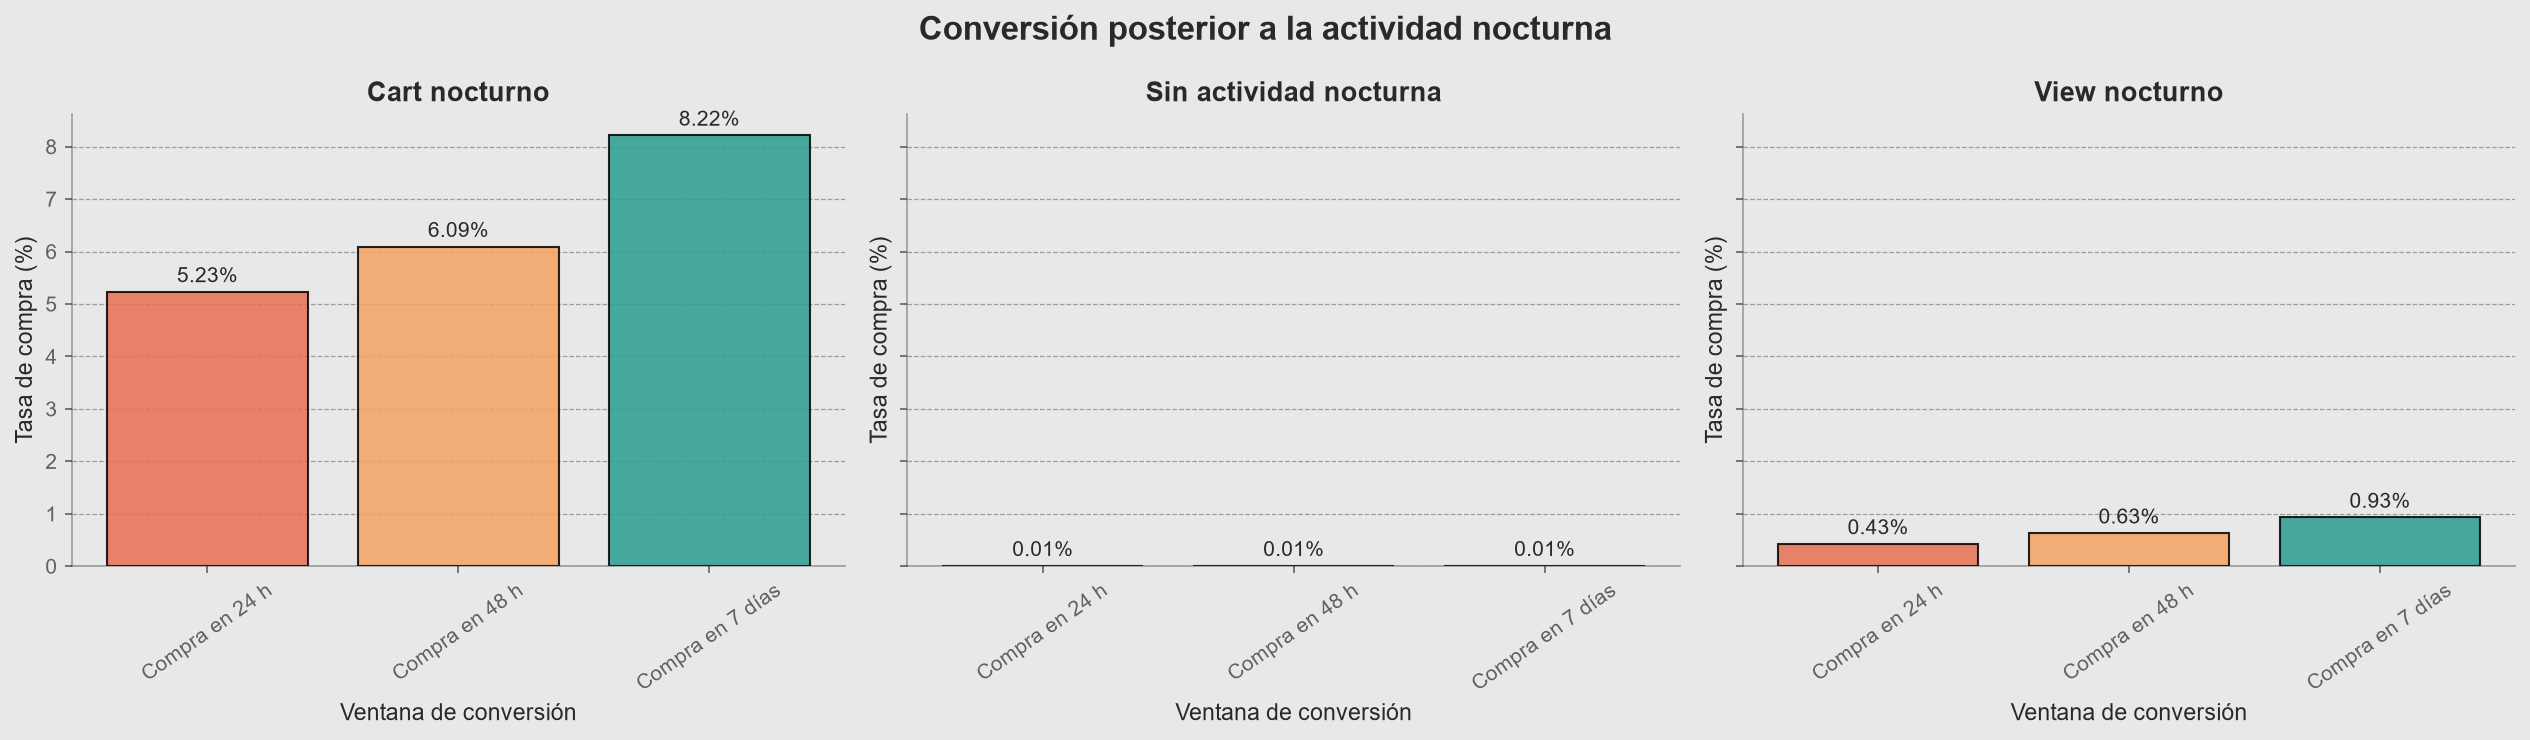

In [83]:
import matplotlib.pyplot as plt

# Orden y nombres de los grupos
grupos = [
    "Cart nocturno",
    "Sin actividad nocturna",
    "View nocturno"
]

metricas = ["purchase_24h", "purchase_48h", "purchase_7d"]
nombres_metricas = ["Compra en 24 h", "Compra en 48 h", "Compra en 7 días"]
colores = ["#E76F51", "#F4A261", "#2A9D8F"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, grupo in zip(axes, grupos):
    datos_grupo = sensitivity_summary[
        sensitivity_summary["night_intent_group"] == grupo
    ].iloc[0]

    valores = [datos_grupo[metrica] for metrica in metricas]

    barras = ax.bar(
        nombres_metricas,
        valores,
        color=colores,
        edgecolor="black",
        alpha=0.85
    )

    ax.set_title(grupo, fontsize=13, fontweight="bold")
    ax.set_xlabel("Ventana de conversión")
    ax.set_ylabel("Tasa de compra (%)")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # Valores sobre las barras
    for barra, valor in zip(barras, valores):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.1,
            f"{valor:.2f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.suptitle(
    "Conversión posterior a la actividad nocturna",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 3.3 Intención nocturna → Compra posterior

### Objetivo del análisis

El objetivo de esta sección fue investigar si la actividad realizada por los usuarios durante la noche puede actuar como una señal temprana de intención de compra y si dicha actividad está asociada con una compra posterior.

Para ello, se identificaron los usuarios que realizaron alguna interacción entre las **21:00 y las 05:59**, diferenciando entre aquellos que únicamente visualizaron productos (`view`) y aquellos que agregaron productos al carrito (`cart`).

Posteriormente, se analizó si estos usuarios realizaron una compra después de su actividad nocturna dentro de ventanas de **24 horas, 48 horas y 7 días**.

---

### Hallazgo principal

El análisis encontró una asociación muy marcada entre la **intensidad de la interacción nocturna** y la probabilidad de realizar una compra posteriormente.

| Grupo                  |   Usuarios | Compra ≤24h | Compra ≤48h | Compra ≤7 días |
| ---------------------- | ---------: | ----------: | ----------: | -------------: |
| Sin actividad nocturna |    126,484 |      0.009% |      0.009% |         0.011% |
| View nocturno          |     26,976 |      0.426% |      0.630% |         0.930% |
| **Cart nocturno**      | **10,321** |  **5.232%** |  **6.094%** |     **8.216%** |

Los resultados muestran un patrón consistente:

**Sin actividad nocturna → View nocturno → Cart nocturno**

A medida que aumenta la intensidad de la interacción nocturna, también aumenta la proporción de usuarios que posteriormente realizan una compra.

---

### Evidencia de intención

El comportamiento de los usuarios que agregaron productos al carrito durante la noche resulta especialmente relevante.

El **5.23%** de los usuarios con `cart` nocturno realizó una compra dentro de las siguientes 24 horas. Esta proporción aumenta a **6.09%** cuando se amplía la ventana a 48 horas y alcanza **8.22%** dentro de los siguientes 7 días.

En comparación, solamente el **0.0087%** de los usuarios sin actividad nocturna realizó una compra dentro de las siguientes 24 horas.

Esto representa una diferencia de aproximadamente **5.22 puntos porcentuales** frente al grupo sin actividad nocturna y un **lift relativo de aproximadamente 601.6×**.

El lift debe interpretarse con precaución debido a que la tasa de referencia es extremadamente pequeña. Por esta razón, la diferencia absoluta y las tasas de conversión son métricas más apropiadas para comunicar el hallazgo principal.

---

### Interpretación de negocio

Los resultados sugieren que determinadas interacciones realizadas durante la noche pueden contener información relevante sobre la **intención futura de compra**.

En particular, agregar un producto al carrito durante la noche parece ser una señal mucho más fuerte que simplemente visualizar un producto.

Esto puede representar un comportamiento como:

**Exploración nocturna → intención → interrupción → compra posterior**

Es posible que algunos usuarios utilicen el período nocturno para investigar productos, comparar alternativas o construir su carrito, y posteriormente completen la compra en otro momento.

Sin embargo, esta interpretación debe considerarse como una **hipótesis de comportamiento**, no como una relación causal demostrada.

---

### Implicación para Marketing y Ventas

Este hallazgo presenta una oportunidad para utilizar el comportamiento del cliente como mecanismo de **priorización comercial**.

En lugar de tratar a todos los usuarios que abandonan una sesión de la misma manera, el negocio podría identificar usuarios que hayan mostrado señales fuertes de intención durante la noche, particularmente aquellos que hayan agregado productos al carrito.

Por ejemplo, un sistema de marketing podría identificar:

> **Usuario con carrito nocturno + sin compra inmediata**

como un segmento de alta prioridad para acciones de recuperación.

Entre las posibles estrategias se encuentran:

* campañas de remarketing durante las horas posteriores a la actividad nocturna;
* recordatorios personalizados de productos agregados al carrito;
* recuperación de carritos abandonados;
* personalización de comunicaciones según productos previamente interactuados;
* priorización de usuarios con señales de alta intención dentro de campañas comerciales;
* evaluación de incentivos únicamente cuando exista evidencia de que son necesarios para convertir.

La lógica no sería simplemente **"contactar a todos los usuarios nocturnos"**, sino utilizar la intensidad del comportamiento como una señal para priorizar recursos.

---

### Oportunidad para Customer Propensity Modeling

Este análisis también aporta evidencia para una posible línea futura de Machine Learning.

En la sección anterior observamos que la **recurrencia** estaba asociada con una mayor probabilidad de compra. En este análisis encontramos que la **actividad nocturna y, especialmente, el comportamiento de carrito**, también contienen información asociada con una compra posterior.

Esto plantea una posible pregunta predictiva:

> **¿Podemos estimar la probabilidad de compra de un usuario utilizando su comportamiento observado hasta un determinado momento?**

Algunas variables potencialmente útiles podrían incluir:

* número de sesiones;
* número de visualizaciones;
* número de productos diferentes interactuados;
* número de carritos;
* número de abandonos;
* actividad nocturna;
* tiempo desde la última interacción;
* frecuencia de interacción;
* categorías o productos interactuados;
* comportamiento histórico del usuario.

Esta hipótesis deberá evaluarse posteriormente mediante una definición temporal adecuada del problema, evitando utilizar información que solamente estaría disponible después de la compra (**data leakage**).

Por tanto, el hallazgo de esta sección **no constituye todavía un modelo predictivo**, pero sí proporciona una señal relevante para justificar la investigación de un futuro modelo de **Purchase Propensity**.

---

### Limitaciones

Este análisis presenta varias limitaciones que deben considerarse antes de convertir el hallazgo en una estrategia definitiva.

1. **Asociación, no causalidad.**
   Los resultados muestran una relación entre comportamiento nocturno y compra posterior, pero no demuestran que la actividad nocturna provoque la compra.

2. **La sesión no representa necesariamente una sesión temporal real.**
   El proyecto determinó previamente que `user_session` no era una medida temporal suficientemente fiable, por lo que este análisis se realiza principalmente siguiendo el comportamiento del usuario mediante `user_id` y `event_time`.

3. **No existe un `order_id`.**
   Por ello, las compras se analizan mediante eventos `purchase` y no mediante pedidos físicos.

4. **La ventana nocturna es una definición analítica.**
   Se utilizó el intervalo 21:00–05:59 como definición operativa de actividad nocturna. Esta definición podría modificarse dependiendo del comportamiento real del negocio.

5. **La compra posterior no implica necesariamente que corresponda al mismo producto.**
   El análisis identifica una compra posterior del usuario, pero todavía no determina si corresponde exactamente al producto agregado al carrito durante la noche.

---

### Conclusión

El análisis identifica una señal de comportamiento potencialmente muy relevante para el negocio:

> **Los usuarios que muestran una intención fuerte de compra durante la noche, particularmente mediante un `cart`, presentan una probabilidad considerablemente mayor de realizar una compra posteriormente.**

El comportamiento se mantiene al ampliar la ventana temporal desde 24 horas hasta 7 días, pasando de **5.23% a 8.22%** para los usuarios con carrito nocturno.

Por su potencial aplicación en **remarketing, recuperación de carritos, priorización de clientes y personalización comercial**, este hallazgo merece ser considerado como una de las principales oportunidades identificadas durante el análisis de clientes.

A nivel analítico, también proporciona una base para investigar posteriormente un sistema de **propensión de compra**, donde diferentes señales de comportamiento puedan combinarse para estimar qué usuarios presentan mayor probabilidad de conversión.


## **4. Insights de customer analysis**

#### **4.1 Resumen de los principales hallazgos**

> **Objetivo:** resumir los insights más relevantes encontrados durante el análisis de clientes, priorizando aquellos que tengan implicaciones para el negocio.

### **Insight 1 — Recurrencia y probabilidad de compra**

**Hallazgo:**

La recurrencia está asociada con una mayor probabilidad de compra. Los usuarios con tres o más sesiones presentan una tasa de compra considerablemente superior a la de los usuarios de una o dos sesiones.

**Evidencia:**

- 1 sesión → **2.13%** Purchase Rate.
- 2 sesiones → **5.63%** Purchase Rate.
- 3+ sesiones → **24.33%** Purchase Rate.
- Usuarios con una sola sesión: **108,362 (66.16%)**.
- Usuarios con dos o más sesiones: **55,403 (33.83%)**.
- Revenue promedio por usuario:
    - 1 sesión: **Bs. 0.75**.
    - 2 sesiones: **Bs. 2.07**.
    - 3+ sesiones: **Bs. 16.26**.
- Productos distintos interactuados por usuario:
    - 1 sesión: **1.98**.
    - 2 sesiones: **3.76**.
    - 3+ sesiones: **23.59**.

**Interpretación:**

Los usuarios recurrentes interactúan con una mayor variedad de productos, generan más eventos de compra y presentan una mayor probabilidad de conversión. Sin embargo, el análisis es descriptivo y no demuestra que aumentar el número de sesiones provoque necesariamente una compra.

**Implicación de negocio:**

Marketing y CRO podrían priorizar estrategias de recuperación y remarketing para usuarios que ya mostraron señales de recurrencia. También sería conveniente facilitar el retorno al sitio mediante recordatorios de productos, carritos abandonados y comunicaciones personalizadas.

#### **Insight 2 — Intención nocturna y compra posterior**

**Hallazgo:**

Los usuarios que muestran una mayor intensidad de interacción durante la noche presentan una mayor proporción de compras posteriores.

**Evidencia:**

| Grupo | Usuarios | Compra ≤24h | Compra ≤48h | Compra ≤7 días |
|---|---:|---:|---:|---:|
| Sin actividad nocturna | 126,484 | 0.009% | 0.009% | 0.011% |
| View nocturno | 26,976 | 0.426% | 0.630% | 0.930% |
| Cart nocturno | 10,321 | 5.232% | 6.094% | 8.216% |

**Interpretación:**

Existe un patrón consistente entre la intensidad de la interacción nocturna y la compra posterior: **sin actividad nocturna → view nocturno → cart nocturno**. El carrito nocturno presenta la señal más fuerte de intención, aunque la relación observada es asociativa y no causal.

**Implicación de negocio:**

El negocio podría priorizar para remarketing a los usuarios con carrito nocturno que no compraron inmediatamente. Las acciones podrían incluir recuperación de carritos, recordatorios personalizados y comunicaciones durante las horas posteriores a la interacción. Estas estrategias deberían validarse mediante experimentos controlados.

#### **Insight 3 — Concentración del revenue entre compradores de mayor valor**

**Hallazgo:**

El revenue está concentrado en una proporción reducida de los compradores. Los compradores con mayor revenue acumulado representan una parte significativa de los ingresos totales.

**Evidencia:**

- El **1%** de los compradores genera el **10.55%** del revenue.
- El **5%** genera el **29.14%**.
- El **10%** genera el **42.44%**.
- El **20%** genera el **58.93%**.
- El **50%** genera el **84.65%**.
- Revenue total de los compradores: **Bs. 621,549.60**.
- El 10% superior corresponde a **1,104 compradores** y genera **Bs. 263,768.62**.

**Interpretación:**

El valor económico no se distribuye uniformemente entre los compradores. Una parte relativamente pequeña concentra una proporción importante de los ingresos. Este análisis es retrospectivo y no permite afirmar todavía que estos usuarios sean más fieles o tengan un mayor valor futuro.

**Implicación de negocio:**

Se recomienda analizar con mayor detalle la recurrencia, frecuencia de compra y comportamiento temporal de estos compradores. Posteriormente podrían desarrollarse estrategias diferenciadas de retención, personalización y protección de clientes de alto valor.

#### **Insight 4 — Predominio de usuarios de una sola sesión y baja conversión global**

**Hallazgo:**

La mayoría de los usuarios interactúa durante una sola sesión y no realiza compras durante el período analizado.

**Evidencia:**

- Usuarios totales: **163,781**.
- Compradores: **11,040**.
- No compradores: **152,741**.
- Tasa de conversión por usuario: **6.74%**.
- Usuarios con una sola sesión: **66.16%**.
- Usuarios recurrentes: **33.83%**.

**Interpretación:**

El principal desafío se encuentra en transformar la primera interacción en una segunda visita y, posteriormente, en una compra. La baja conversión global también indica que la mayoría de los usuarios no avanza hasta la etapa transaccional durante el período observado.

**Implicación de negocio:**

Las acciones de CRO deberían enfocarse en reducir la fricción de la primera visita, mejorar la recuperación de usuarios y facilitar el retorno al sitio. También sería relevante evaluar campañas de remarketing diferenciadas para usuarios que visualizaron productos, agregaron artículos al carrito o mostraron recurrencia.

#### **4.2 Priorización de insights**

No todos los hallazgos tienen el mismo valor para el negocio. Se recomienda priorizarlos considerando:

- **Impacto potencial:** cuánto podría afectar ingresos, conversión, retención o eficiencia comercial.
- **Evidencia:** qué tan sólida es la evidencia disponible.
- **Accionabilidad:** qué tan fácil es convertir el insight en una acción concreta.
- **Necesidad de validación:** qué tan necesario es realizar experimentos o análisis adicionales.

| Insight | Impacto | Evidencia | Accionabilidad | Prioridad |
|---|---|---|---|---|
| Recurrencia y probabilidad de compra | Alto | Alta | Alta | Alta |
| Intención nocturna y compra posterior | Alto | Media | Alta | Alta |
| Concentración del revenue | Alto | Alta | Media | Alta |
| Predominio de usuarios de una sola sesión y baja conversión | Alto | Alta | Media | Alta |

## **5. Conclusiones y oportunidades**

## 5. Conclusiones y oportunidades

### 5.1 Conclusiones

#### Conclusión 1 — La recurrencia es la principal señal de intención

La cantidad de sesiones está fuertemente asociada con la probabilidad de compra. Los usuarios con una sola sesión presentan una tasa de compra del **2,13%**, mientras que quienes tienen dos sesiones alcanzan el **5,63%** y quienes registran tres o más sesiones llegan al **24,33%**.

Además, el grupo de tres o más sesiones concentra aproximadamente el **78,5% de los ingresos**, aunque representa cerca del **18,3% de los usuarios analizados**.

#### Conclusión 2 — El comportamiento nocturno permite identificar distintos niveles de intención

El **22,9% de los usuarios** registró actividad nocturna. Dentro de este grupo, los usuarios que agregaron productos al carrito durante la noche presentaron una tasa de compra posterior en 24 horas del **5,23%**, frente al **0,43%** de quienes únicamente realizaron vistas nocturnas y al **0,009%** de quienes no tuvieron actividad nocturna.

Esta diferencia muestra que la interacción con el carrito es una señal de intención considerablemente más fuerte que una simple visualización. Sin embargo, la relación observada es asociativa y debe validarse mediante experimentos.

#### Conclusión 3 — Los ingresos están concentrados en una parte reducida de los compradores

El **10% de los compradores con mayor facturación** genera el **42,4% de los ingresos**, mientras que el 20% concentra el **58,9%** y el 50% concentra el **84,7%**.

Esto indica que no todos los compradores tienen el mismo valor económico para el negocio. La recurrencia, la cantidad de productos interactuados y la frecuencia de eventos de compra caracterizan especialmente a los usuarios de mayor valor.

#### Conclusión general

El análisis permitió comprender que la compra está precedida por señales de comportamiento observables. La recurrencia de sesiones, la interacción con múltiples productos, el uso del carrito y la actividad nocturna asociada con carritos son indicadores de mayor intención comercial.

También se observó que la base de usuarios es mayoritariamente no compradora: **11.040 usuarios compraron, equivalente al 6,74% de los 163.781 usuarios analizados**. Por lo tanto, existe una oportunidad tanto para convertir usuarios con señales de intención como para aumentar la recurrencia de quienes todavía no compraron.

La principal novedad es que la probabilidad de compra no se distribuye de forma homogénea: se concentra en usuarios recurrentes y en segmentos que muestran comportamientos más cercanos a la decisión de compra.

### 5.2 Oportunidades de negocio

A partir de los insights encontrados, se identifican las siguientes oportunidades:

#### Oportunidad 1 — Recuperación priorizada de carritos nocturnos

**Problema / oportunidad:**

Los usuarios que interactúan con el carrito durante la noche pueden abandonar la compra sin finalizarla, aunque presentan una intención superior a la del resto de los usuarios.

**Evidencia:**

El segmento `Cart nocturno` presenta una tasa de compra posterior en 24 horas del **5,23%**, frente al **0,87% de la línea base expresada como 0,0087 en proporción**. La tasa alcanza el **6,09% en 48 horas** y el **8,22% en 7 días**.

**Acción propuesta:**

Implementar recordatorios personalizados para usuarios con actividad de carrito nocturna, priorizando mensajes durante la mañana siguiente y mostrando los productos agregados, disponibilidad y posibles incentivos.

**Métrica de éxito:**

Tasa de recuperación de carrito, compras posteriores en 24 horas, ingresos incrementales y margen por usuario impactado.

**Método de validación:**

Experimento A/B entre usuarios que reciben el recordatorio y un grupo de control sin comunicación.

#### Oportunidad 2 — Programas de activación para aumentar la recurrencia

**Problema / oportunidad:**

La mayoría de los usuarios registra una sola sesión y presenta una baja tasa de compra.

**Evidencia:**

Los usuarios con una sesión tienen una tasa de compra del **2,13%**, frente al **24,33%** de los usuarios con tres o más sesiones. La tasa de compra aumenta progresivamente con la recurrencia.

**Acción propuesta:**

Diseñar campañas de retención y remarketing para incentivar una segunda y tercera visita, utilizando recomendaciones de productos, favoritos, alertas de precio o recordatorios de productos vistos.

**Métrica de éxito:**

Tasa de retorno, porcentaje de usuarios que alcanzan dos o más sesiones, tasa de conversión y revenue por usuario.

**Método de validación:**

Prueba controlada por cohortes o experimento A/B con seguimiento durante 7 y 30 días.

#### Oportunidad 3 — Segmentación por valor e intención

**Problema / oportunidad:**

Los ingresos están altamente concentrados y las acciones comerciales genéricas pueden no ser eficientes para todos los usuarios.

**Evidencia:**

El 10% de los compradores con mayor facturación genera el **42,4% de los ingresos**. Además, los usuarios con tres o más sesiones concentran aproximadamente el **78,5% de la facturación total**.

**Acción propuesta:**

Crear segmentos diferenciados de alto valor, alta intención y baja intención para personalizar recomendaciones, incentivos, campañas de fidelización y acciones de recuperación.

**Métrica de éxito:**

Ingresos incrementales, frecuencia de compra, valor promedio por usuario, tasa de recompra y retorno de la inversión de las campañas.

**Método de validación:**

Piloto segmentado con grupo de control y análisis de ingresos incrementales antes y después de la intervención.

### 5.3 Oportunidad futura — Purchase Propensity Modeling

Durante el análisis se identificaron diferentes señales de comportamiento asociadas con una mayor probabilidad de compra, particularmente:

- recurrencia del usuario;
- cantidad de sesiones;
- intensidad de interacción;
- cantidad de productos interactuados;
- actividad nocturna;
- comportamiento de carrito;
- historial de interacción;
- frecuencia de eventos de compra.

Esto plantea una oportunidad futura para desarrollar un modelo de Purchase Propensity capaz de estimar la probabilidad de que un usuario realice una compra dentro de un horizonte temporal determinado.

#### Pregunta analítica futura

¿Podemos estimar la probabilidad de compra de un usuario utilizando únicamente la información disponible hasta un determinado momento?

#### Posibles aplicaciones

- priorización de usuarios de alta intención;
- remarketing;
- recuperación de carritos;
- personalización;
- priorización comercial;
- optimización de campañas;
- asignación eficiente de incentivos.

#### Consideraciones metodológicas

Antes de desarrollar el modelo será necesario:

- definir claramente el momento de predicción;
- definir el horizonte de predicción;
- construir una variable objetivo temporal;
- evitar *data leakage*;
- establecer un *baseline* simple;
- comparar modelos predictivos contra dicho *baseline*;
- evaluar no solamente la performance estadística, sino también la utilidad económica para el negocio.

Esta oportunidad queda registrada como hipótesis futura, no como una solución ML ya validada.

### 5.4 Próximos pasos

| Prioridad | Acción | Objetivo | KPI / criterio de éxito |
|---:|---|---|---|
| 1 | Implementar un piloto de recuperación de carritos nocturnos | Aumentar las compras posteriores al abandono | Conversión en 24 horas e ingresos incrementales |
| 2 | Diseñar una campaña para incentivar la segunda y tercera sesión | Aumentar la recurrencia de los usuarios | Porcentaje de usuarios con dos o más sesiones |
| 3 | Crear segmentos por intención y valor | Personalizar las acciones comerciales | Conversión, revenue por usuario y ROI |
| 4 | Diseñar un dataset temporal para propensity modeling | Evaluar la viabilidad de un modelo predictivo | Lift frente al baseline y utilidad económica |

### 5.5 Limitaciones generales del Customer Analysis

- El dataset no contiene `order_id`, por lo que los eventos `purchase` no pueden interpretarse directamente como pedidos físicos.
- `user_session` no fue utilizada como medida fiable de duración temporal de una sesión.
- Las relaciones encontradas son principalmente descriptivas y asociativas; no implican causalidad.
- El **2,44% de los eventos** presenta una sesión faltante, por lo que algunos análisis basados en sesiones pueden estar afectados.
- Algunas hipótesis requieren validación mediante experimentación o análisis temporal adicional.
- Las recomendaciones de negocio deben validarse mediante métricas de resultado antes de considerarse efectivas.

### 5.6 Cierre

El objetivo del Customer Analysis no es únicamente describir quién compra, sino comprender qué comportamientos preceden a la compra y qué señales pueden utilizarse para mejorar la toma de decisiones comerciales.

Los resultados muestran que la recurrencia, la interacción con el carrito y la intensidad de navegación son señales relevantes de intención. Estas señales permiten priorizar acciones de recuperación, desarrollar estrategias de retención y diferenciar a los usuarios según su valor potencial.

El siguiente paso consiste en transformar estos hallazgos descriptivos en experimentos medibles y, posteriormente, evaluar si pueden utilizarse para construir modelos de propensión de compra que generen valor económico para el negocio.